Data Science
---
 based on hw3.pdf
---
The data set for this code is:
---
🟩NVIDIA & AMD🟥 GPUs Full Specs💠
---
[Link for dataset](https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs/data)
---
Sources: [link](https://www.techpowerup.com/gpu-specs/)



## 1. Initial set up

In [1]:
# Install kaggle library
!pip install kaggle

In [2]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
# Download the dataset
!kaggle datasets download alanjo/graphics-card-full-specs
!unzip graphics-card-full-specs.zip

Dataset URL: https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs
License(s): CC0-1.0
100% 69.2k/69.2k [00:00<00:00, 59.0MB/s]

Archive:  graphics-card-full-specs.zip
  inflating: gpu_specs_v6.csv        
  inflating: gpu_specs_v7.csv        


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('gpu_specs_v7.csv')
print(df.columns.tolist())

['manufacturer', 'productName', 'releaseYear', 'memSize', 'memBusWidth', 'gpuClock', 'memClock', 'unifiedShader', 'tmu', 'rop', 'pixelShader', 'vertexShader', 'igp', 'bus', 'memType', 'gpuChip']


## 2. Exploratory Data Analysis


In [6]:
# --- Part 2: Exploratory Data Analysis (EDA) ---

print("--- Structural Analysis ---")

# Number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}\n")

# Data types
print("--- Data Types ---")
print(df.dtypes, "\n")

# Missing values
print("--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0], "\n") # Showing only columns with missing data

# Statistical summary (for numerical columns only)
print("--- Statistical Summary ---")
display(df.describe())

--- Structural Analysis ---
Number of rows: 3056
Number of columns: 16

--- Data Types ---
manufacturer      object
productName       object
releaseYear      float64
memSize          float64
memBusWidth      float64
gpuClock           int64
memClock         float64
unifiedShader    float64
tmu                int64
rop                int64
pixelShader      float64
vertexShader     float64
igp               object
bus               object
memType           object
gpuChip           object
dtype: object 

--- Missing Values ---
releaseYear        44
memSize           441
memBusWidth      2868
memClock          441
unifiedShader     824
pixelShader      2232
vertexShader     2232
memType           441
dtype: int64 

--- Statistical Summary ---


,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader
count,3012.000000,2615.000000,188.000000,3056.000000,2615.000000,2232.000000,3056.000000,3056.000000,824.000000,824.000000
mean,2011.371182,4.265732,798.808511,694.622709,922.341874,1321.100358,55.336060,20.855039,6.739078,2.622573
std,6.643131,12.171637,1881.433321,412.019546,553.027257,2368.021362,93.347381,28.178347,8.091586,2.579388
min,1986.000000,0.000032,32.000000,10.000000,5.000000,8.000000,0.000000,0.000000,0.000000,0.000000
25%,2007.000000,0.256000,128.000000,400.000000,475.000000,160.000000,8.000000,4.000000,2.000000,0.000000
50%,2012.000000,1.024000,192.000000,625.000000,900.000000,448.000000,24.000000,8.000000,4.000000,2.000000
75%,2016.000000,4.000000,256.000000,903.250000,1253.000000,1536.000000,64.000000,32.000000,8.000000,4.000000
max,2025.000000,288.000000,8192.000000,2340.000000,2525.000000,20480.000000,1216.000000,192.000000,48.000000,24.000000


--- Distribution Analysis ---

Feature: releaseYear
Skewness: -0.21
Kurtosis: -0.23


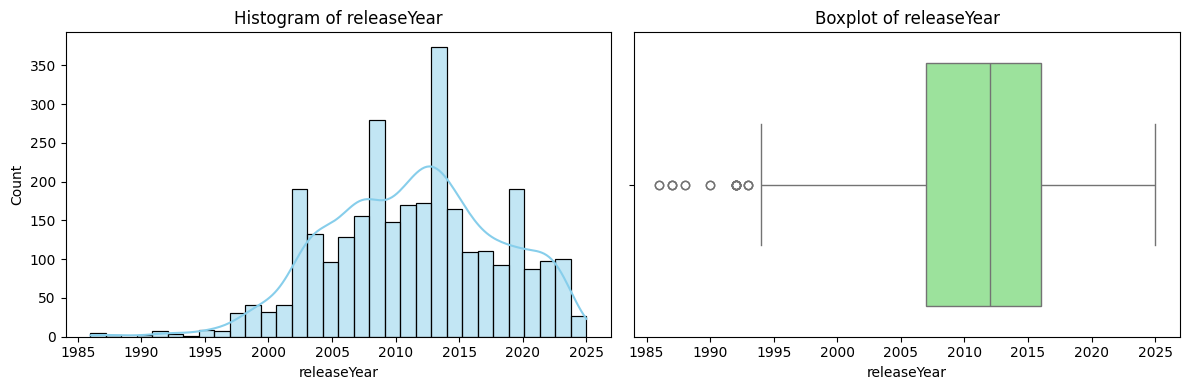


Feature: memSize
Skewness: 10.31
Kurtosis: 164.45


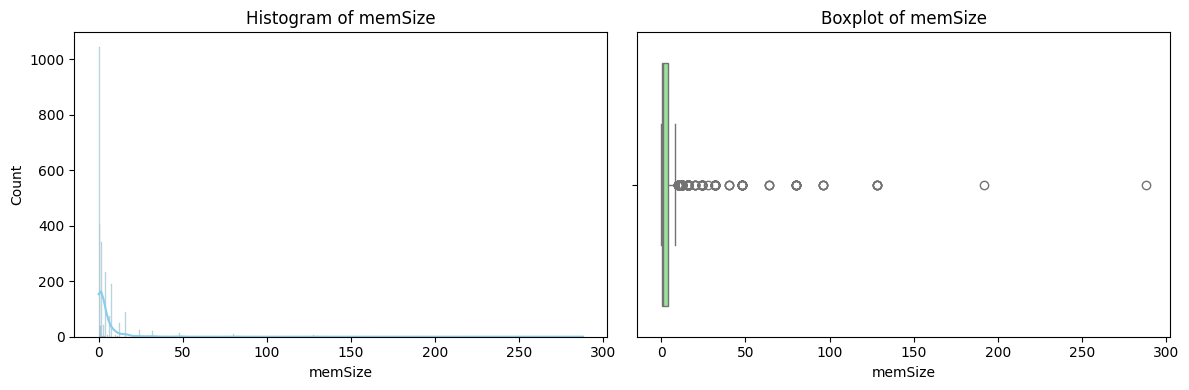


Feature: memBusWidth
Skewness: 2.98
Kurtosis: 7.83


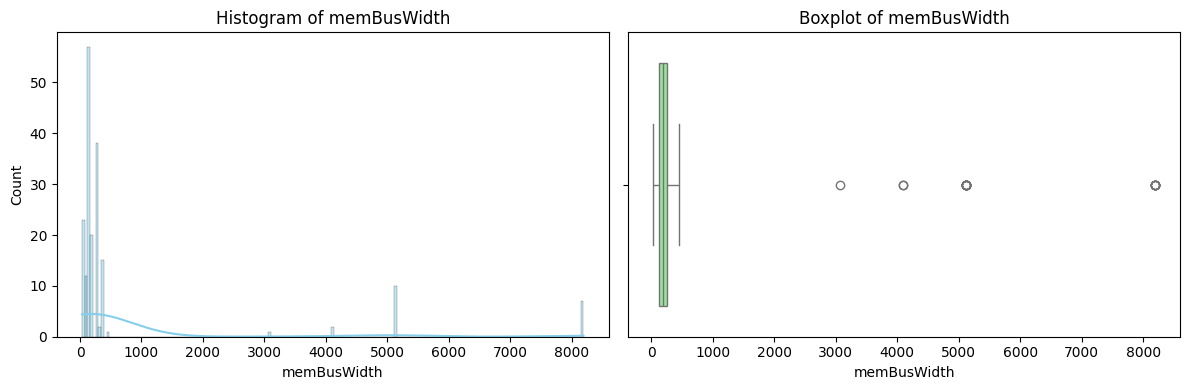


Feature: gpuClock
Skewness: 1.12
Kurtosis: 1.68


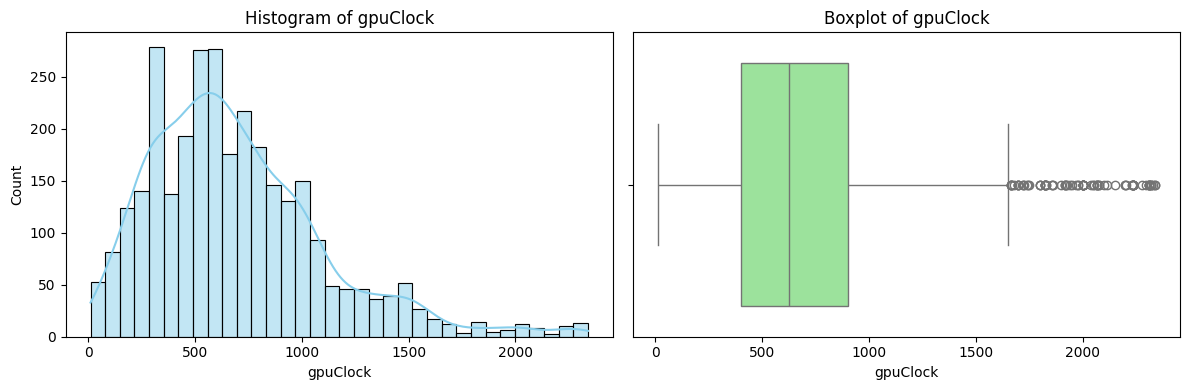


Feature: memClock
Skewness: 0.46
Kurtosis: -0.46


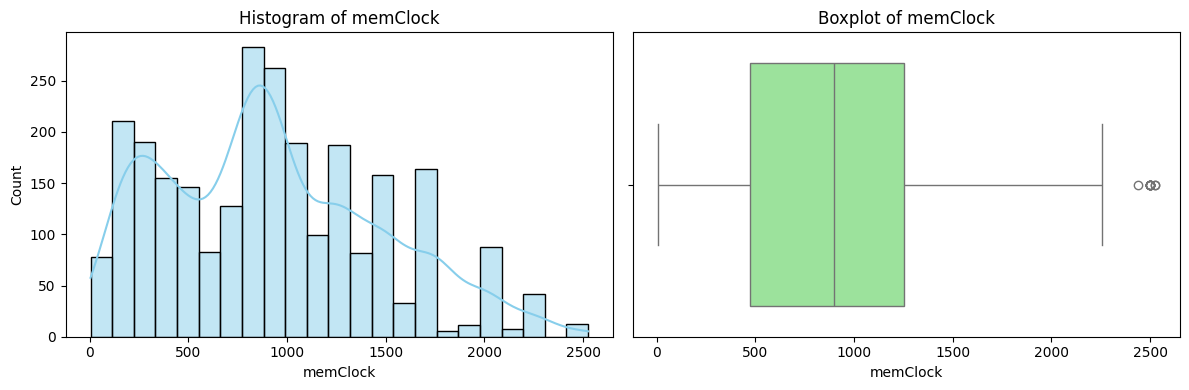


Feature: unifiedShader
Skewness: 4.12
Kurtosis: 21.60


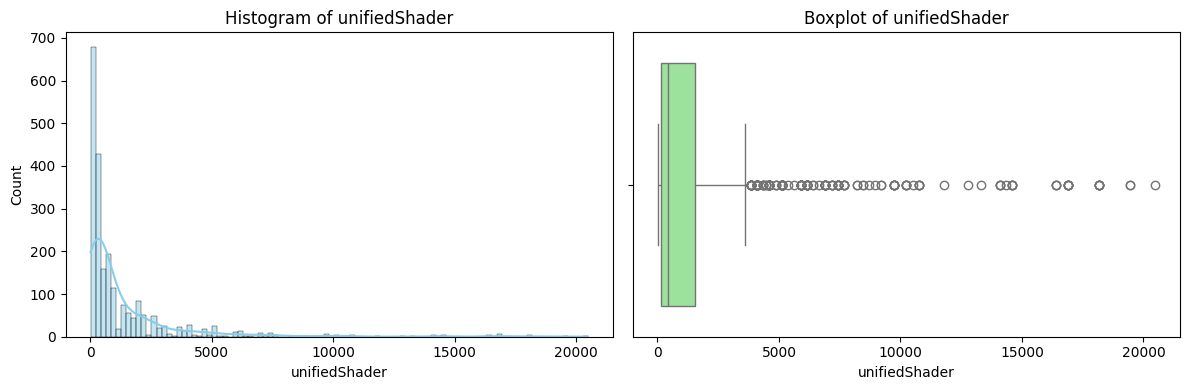


Feature: tmu
Skewness: 4.61
Kurtosis: 34.97


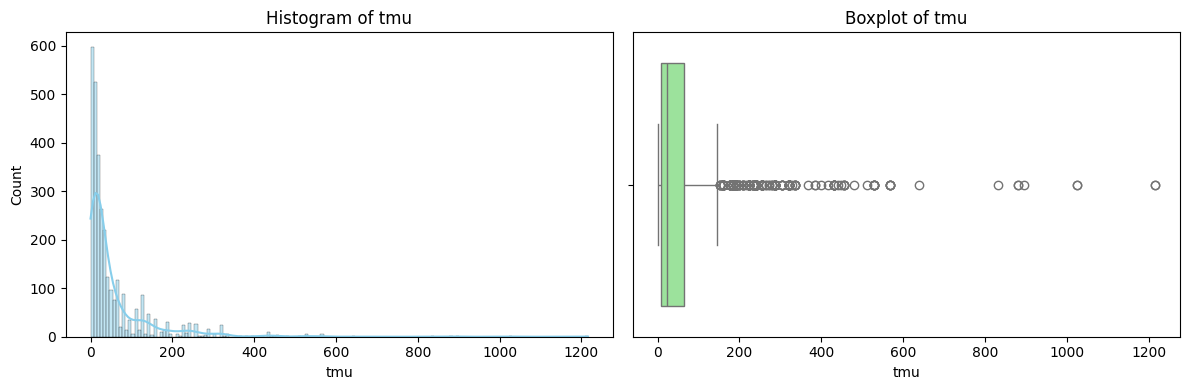


Feature: rop
Skewness: 2.72
Kurtosis: 9.30


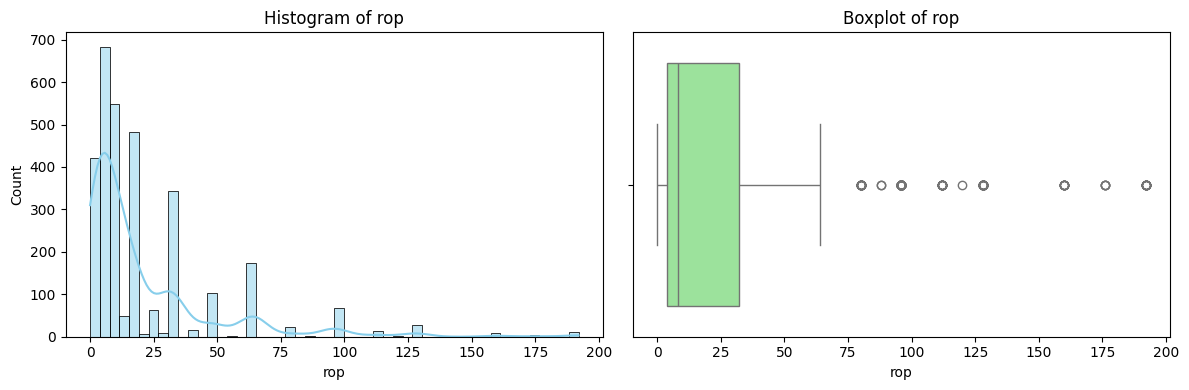


Feature: pixelShader
Skewness: 2.83
Kurtosis: 9.66


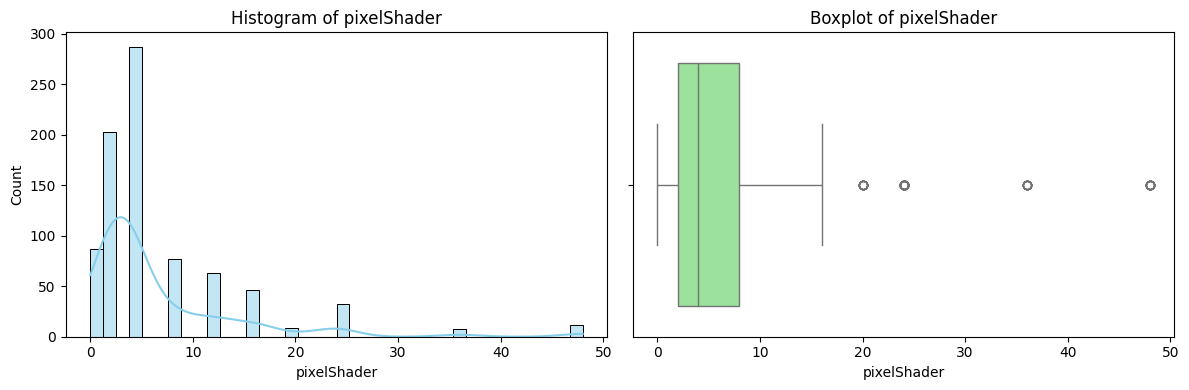


Feature: vertexShader
Skewness: 1.42
Kurtosis: 5.08


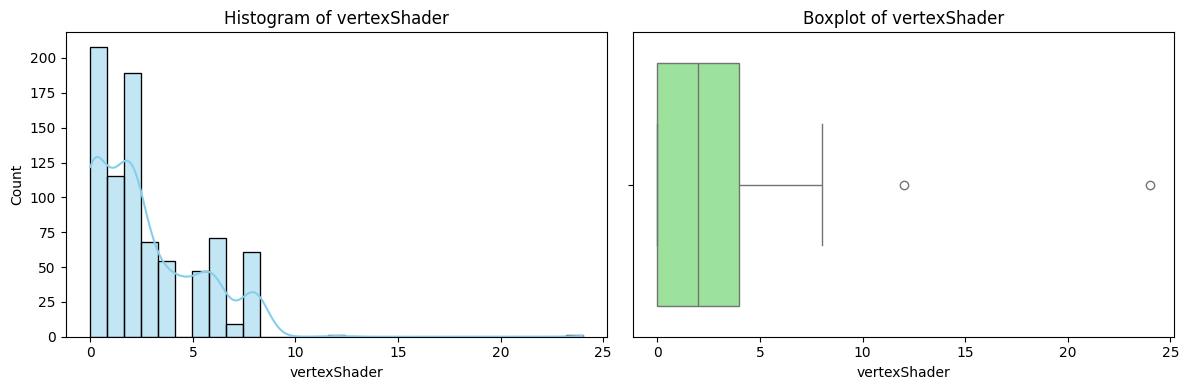

In [7]:

print("--- Distribution Analysis ---")

# Select only the numerical columns for distribution analysis
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    # Ignore missing values
    skewness = df[col].skew()
    kurt = df[col].kurtosis()

    print(f"\nFeature: {col}")
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurt:.2f}")

    # Create a figure with 2 subplots (Histogram and Boxplot side-by-side)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram - shows data distribution
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {col}')

    # Boxplot - excellent for spotting outliers and extreme values
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

Outlier Exploration & Distribution Analysis

Based on the statistical calculations and the generated histograms and boxplots, we can see distinct patterns regarding the distribution and extreme values in our dataset:

* **Extreme Values:** The boxplots reveal significant outliers, most notably in memSize (VRAM), unifiedShader, and tmu. For example, memSize shows extreme outliers extending far beyond the upper whisker. In the context of GPUs, these are not errors but rather represent ultra high end workstation or AI focused accelerators (data center GPUs) compared to the standard consumer graphics cards that make up the bulk of the dataset.
* **Heavy Tails:** We see a massive right skewness in several features. memSize has an extreme positive skewness of 10.31 and a kurtosis of 164.45. Similarly, unifiedShader (Skew: 4.12) and tmu (Skew: 4.61) show long right tails. This perfectly mirrors the hardware market, where exponential jumps in architecture apply to a very small, exclusive subset of flagship products.
* **Possible Noise & Measurement Artifacts:** Because this dataset catalogs official hardware specifications rather than live, real time sensor readings, traditional "noise" (electrical interference or faulty sensors).
* **Data entry Problems:** While manual data entry errors are always a possibility (missing a decimal point / confusing MB with GB), the identified outliers are consistent with the known extremes of modern GPU manufacturing. The dataset correctly reflects the disparity between decades old legacy hardware and cutting edge modern architectures.

## 3. Dimensionality Reduction

In [8]:
# --- Data Preprocessing (Run this BEFORE PCA) ---
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Save the labels for later analysis
abels_df = df[['manufacturer', 'productName']].copy()

# Feature Engineering - Extract numbers to ensure we have enough features (>8)
df['igp_numeric'] = df['igp'].map({'Yes': 1, 'No': 0})
df['bus_version'] = df['bus'].str.extract(r'(\d+\.\d+)').astype(float)

# Drop text columns and columns that are almost completely empty
cols_to_drop = [
    'manufacturer', 'productName', 'igp', 'bus', 'memType', 'gpuChip',
    'memBusWidth', 'pixelShader', 'vertexShader'
]
df_numeric = df.drop(columns=cols_to_drop)

# Fill missing values with the median of each column
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df_numeric.columns)

# Scaling - removing the mean and scaling to unit variance
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print(f"Data successfully prepared and scaled! Ready for PCA.")
print(f"Final shape of df_scaled: {df_scaled.shape}")

Data successfully prepared and scaled! Ready for PCA.
Final shape of df_scaled: (3056, 9)


--- PCA Variance Metrics ---
PC1: Explained Variance = 0.5034 | Cumulative = 0.5034
PC2: Explained Variance = 0.1206 | Cumulative = 0.6240
PC3: Explained Variance = 0.1123 | Cumulative = 0.7364
PC4: Explained Variance = 0.0759 | Cumulative = 0.8122
PC5: Explained Variance = 0.0672 | Cumulative = 0.8795
PC6: Explained Variance = 0.0635 | Cumulative = 0.9430
PC7: Explained Variance = 0.0301 | Cumulative = 0.9732
PC8: Explained Variance = 0.0180 | Cumulative = 0.9912
PC9: Explained Variance = 0.0088 | Cumulative = 1.0000


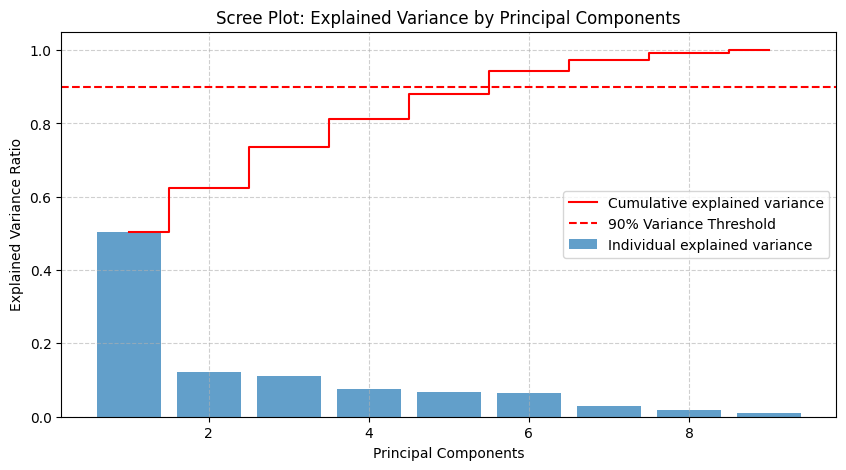

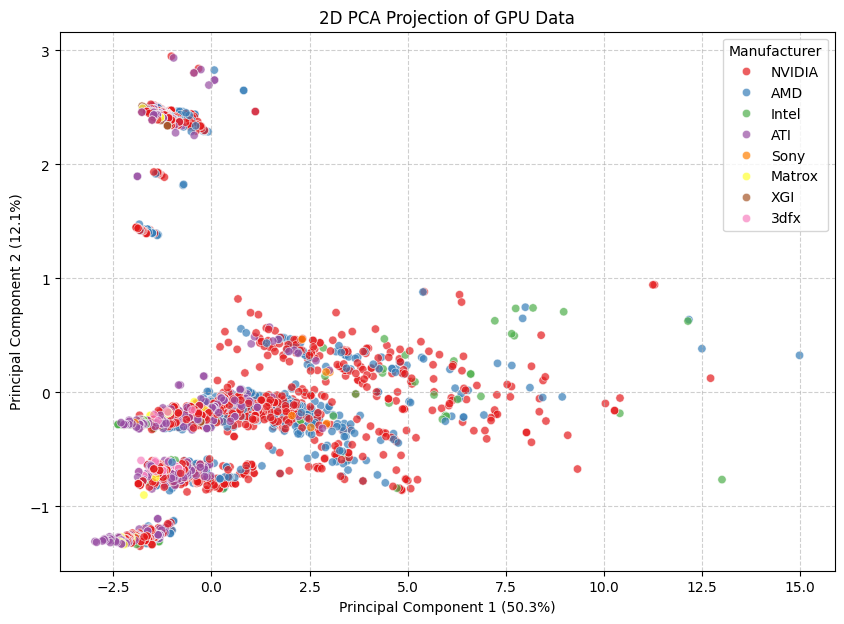

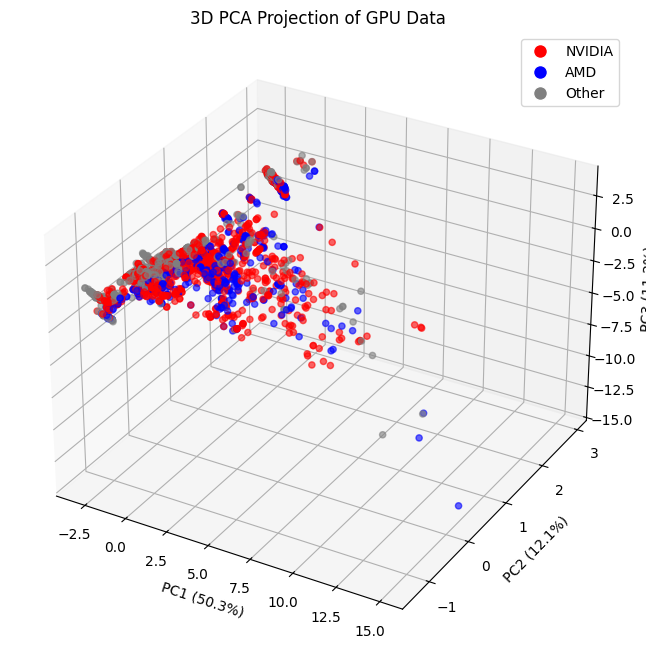

In [9]:
# --- Part 3.1: Principal Component Analysis (PCA) ---

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA - keeping all components initially to calculate variance
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

# Calculate explained variance and cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("--- PCA Variance Metrics ---")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: Explained Variance = {ev:.4f} | Cumulative = {cv:.4f}")

# Scree Plot & Cumulative Variance Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='red', label='Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Projection into 2D
pca_df = pd.DataFrame(data=pca_result[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Manufacturer'] = df['manufacturer'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Manufacturer', data=pca_df, alpha=0.7, palette='Set1')
plt.title('2D PCA Projection of GPU Data')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Projection into 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Create a color map for the manufacturers
colors = {'NVIDIA': 'red', 'AMD': 'blue'}
point_colors = pca_df['Manufacturer'].map(colors).fillna('gray')

scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=point_colors, alpha=0.6, s=20)
ax.set_title('3D PCA Projection of GPU Data')
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]*100:.1f}%)')

# Custom legend for 3D plot
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='NVIDIA'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='AMD'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Other')]
ax.legend(handles=legend_elements, loc='best')
plt.show()

PCA Discussion and Interpretation

**1. How many components are needed & Information Loss**
* Based on our variance metrics and the Scree plot, Principal Component 1 (PC1) is highly dominant, capturing **50.34%** of the total variance. To retain 90% of the original dataset's information, we must keep **6 components** (which give a cumulative variance of 94.30%).
When projecting into 2D, we retain 62.40% of the variance, meaning an information loss of about 37.6%. Moving to 3D captures **73.64%** of the variance, reducing the loss to roughly 26.3%.

**2. Correlated Variables & Interpretation of Major Components:**
The sheer dominance of PC1 (50.34%) indicates heavy correlation among the features. In GPU hardware, features typically scale together: a newer GPU will simultaneously have more `memSize`, higher `gpuClock`, and more `unifiedShader` units.
* **PC1 (Performance/Generation):** This component represents the overall computational power and generational leap of the card.
* **PC2 (Architecture Trade-offs):** Capturing 12.06% of the variance, this component likely highlights architectural differences, such as cards that favor raw clock speed versus massive memory buses.

**3. Global vs. Local Structure & Cluster Separation:**
PCA is a linear technique that excels at preserving **global structure** (e.g., pushing old 2010 GPUs far away from modern 2024 GPUs based on raw specs). However, looking at the 2D and 3D projections colored by manufacturer, there is **no clear cluster separation** between NVIDIA and AMD. This perfectly illustrates PCA's limitation with **local structure**: because both companies release directly competing hardware with nearly identical numerical specifications, PCA maps them to the exact same regions in the reduced space.

**4. Stability, Computational Cost, and Interpretability:**
* **Stability & Cost:** The PCA transformation is highly stable and deterministic. Computationally, it is very cheap and fast, making it highly efficient for this dataset.
* **Interpretability:** While the total variance is easy to grasp, the new axes (PC1, PC2) are abstract linear combinations of 9 features. We lose the direct interpretability of a specific metric like "Megahertz" in exchange for a broader geometric representation.

## 4. Clustering Analysis

Algorithm Explanations (Theory & Assumptions)

**K-Means Clustering**
* **Mathematical Intuition:** A centroid based algorithm that partitions data into K clusters by minimizing the within cluster sum of squares. It iteratively updates cluster centroids to the mean of assigned points.
* **Assumptions:** Assumes clusters are spherical, isotropic, and have roughly similar variances and sizes.
* **Strengths & Weaknesses:** Very fast and scalable for large datasets. However, it requires choosing K in advance, is highly sensitive to outliers, and fails on non linear geometries.

**2. DBSCAN (Density Based Spatial Clustering of Applications with Noise)**
* **Mathematical Intuition:** A density based algorithm that groups points closely packed together. Points in low density regions are marked as noise/outliers.
* **Assumptions:** Assumes clusters are regions of high density separated by regions of low density. It does not assume spherical shapes.
* **Strengths & Weaknesses:** Can find arbitrarily shaped clusters and automatically detects outliers without requiring a predefined K. Weakness: Struggles with clusters of varying densities and is highly sensitive to the eps and min_samples hyperparameters.

**3. Hierarchical Clustering**
* **Mathematical Intuition:** An approach where each point starts as its own cluster, and the closest pairs of clusters are iteratively merged based on a linkage criteria until all form a single root.
* **Assumptions:** Assumes a hierarchical or nested structure within the data based on distance connectivity.
* **Strengths & Weaknesses:** Excellent for interpretability via dendrograms and doesn't require K initially. However, it is computationally expensive, making it slow for massive datasets.

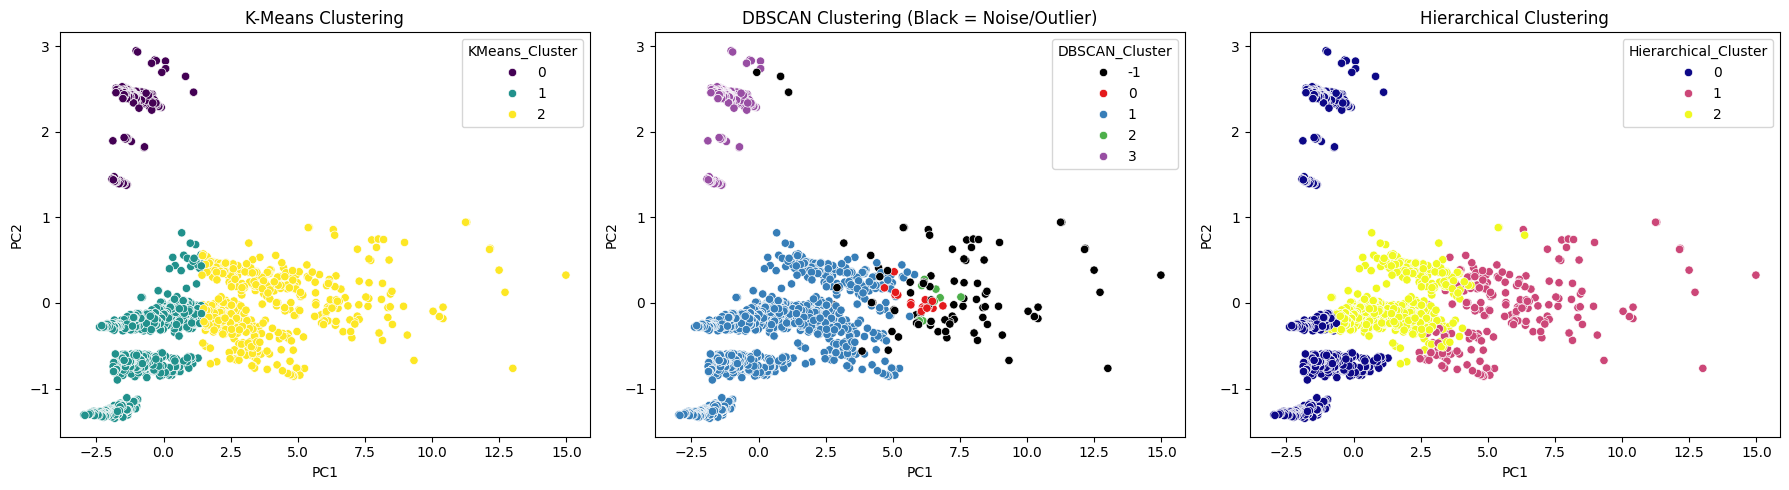

--- Clustering Evaluation ---
K-Means Silhouette Score: 0.353
DBSCAN Silhouette Score: 0.249
Hierarchical Silhouette Score: 0.237

Global Data Variance: 1.000
Average Variance within K-Means clusters: 0.697


In [11]:
# --- Part 4.1: Clustering on Samples & Visualization ---
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(df_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(df_scaled)

# Store labels in our PCA dataframe for 2D visualization
pca_df['KMeans_Cluster'] = kmeans_labels
pca_df['DBSCAN_Cluster'] = dbscan_labels
pca_df['Hierarchical_Cluster'] = hierarchical_labels

# --- Plotting the clusters on PCA projection ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis', data=pca_df, ax=axes[0])
axes[0].set_title('K-Means Clustering')

# Custom palette for DBSCAN to explicitly show noise as black (-1)
dbscan_palette = sns.color_palette("Set1", len(np.unique(dbscan_labels)))
if -1 in dbscan_labels:
    dbscan_palette = ['black'] + sns.color_palette("Set1", len(np.unique(dbscan_labels))-1)

sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', palette=dbscan_palette, data=pca_df, ax=axes[1])
axes[1].set_title('DBSCAN Clustering (Black = Noise/Outlier)')

sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', palette='plasma', data=pca_df, ax=axes[2])
axes[2].set_title('Hierarchical Clustering')

plt.tight_layout()
plt.show()

# --- Evaluation Metrics ---
print("--- Clustering Evaluation ---")
print(f"K-Means Silhouette Score: {silhouette_score(df_scaled, kmeans_labels):.3f}")

if len(set(dbscan_labels)) > 1: # Calculate only if DBSCAN found more than 1 cluster + noise
    print(f"DBSCAN Silhouette Score: {silhouette_score(df_scaled, dbscan_labels):.3f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only 1 cluster or pure noise found)")

print(f"Hierarchical Silhouette Score: {silhouette_score(df_scaled, hierarchical_labels):.3f}\n")

# Evaluating Average Cluster Variance vs Global Variance
global_variance = np.var(df_scaled, axis=0).mean()
cluster_variances = [np.var(df_scaled[kmeans_labels == i], axis=0).mean() for i in range(3)]
avg_cluster_variance = np.mean(cluster_variances)

print(f"Global Data Variance: {global_variance:.3f}")
print(f"Average Variance within K-Means clusters: {avg_cluster_variance:.3f}")


**Why different algorithms produce different clusters:**
The algorithms optimize different objective functions. K Means minimizes variance to create tight, spherical clusters. DBSCAN looks for continuous high density regions and isolates sparse points as noise, ignoring overall variance. Hierarchical clustering builds a connectivity tree based on distances, allowing for multi level nested groupings.

**Sensitivity to hyperparameters:**
Clustering is highly sensitive to initial choices. K-Means drastically changes based on the chosen $K$ (number of clusters) and initialization seeds. DBSCAN is notoriously sensitive to `eps` and `min_samples`; a slight change in `eps` in our GPU dataset could easily merge the entire dataset into one giant cluster or classify half the hardware as noise.

**Cluster geometry & Density vs. Centroid approaches:**
K Means (centroid based) assumes clusters are convex and spherical, dividing the space linearly. It struggles if clusters are elongated or curved. DBSCAN (density based) makes no geometric assumptions, perfectly handling arbitrary shapes and natively filtering outliers. However, because hardware data is a continuous evolution, density based approaches struggle here, making K Means the better fit.

**Situations where clustering may fail:**
1. **The Curse of Dimensionality:** In extremely high dimensional spaces without prior PCA, distance metrics lose meaning, as all points appear roughly equidistant.
2. **Varying Densities:** If one natural cluster is very dense and another is very loose, DBSCAN with a global eps will either miss the loose cluster or merge the dense one with noise.
3. **Overlapping Distributions:** As seen in our dataset with NVIDIA vs. AMD, if distinct logical classes share identical numerical features, unsupervised clustering cannot separate them.

## 5.  Multi-Dimensional Anomaly Detection


5.1 Z-Score Method
Discussion
**Assumption of Gaussianity:**
* The Z Score method assumes that the underlying data follows a Normal distribution. As we saw in our Exploratory Data Analysis (EDA), many of our GPU features (like memSize or unifiedShader) are heavily right skewed and not normally distributed. Because of this extreme skewness, the Z score method might falsely flag many valid high end GPUs as "anomalies" simply because they lie in the heavy right tail of the distribution.

**Why this approach may fail in high dimensions:**
* The Z score is fundamentally a univariate metric (it evaluates one dimension at a time). In high dimensional spaces, a point might not be an extreme outlier in any single dimension, but its a cobination of values across multiple dimensions could be highly anomalous (a GPU with a very low clock speed but a massive amount of VRAM). The standard Z score completely misses these complex multivariate relationships.

**Feature-wise vs. Global Anomaly Detection:**
* **Feature-wise (Z score):** Checks if a data point is an outlier in Feature X / Feature Y / Feature Z independently. It draws a conceptual "bounding box" around the data.
* **Global/Multivariate:** Looks at the entire space simultaneously. It understands the correlation and geometric shape of the data, drawing a boundary that follows the actual data distribution rather than strict horizontal /vertical lines.

--- Z-Score Anomaly Detection ---
Threshold set to: Z > 3.0
Number of anomalies detected by Z-Score: 166 (out of 3056 GPUs)

Sample of GPUs flagged as anomalies by Z-Score:


,manufacturer,productName
0,NVIDIA,GeForce RTX 5090
1,NVIDIA,GeForce RTX 5080
2,NVIDIA,GeForce RTX 5070
3,NVIDIA,GeForce RTX 5060 Mobile
4,NVIDIA,GeForce RTX 5060
6,NVIDIA,RTX 1000 Mobile Ada Generation
7,NVIDIA,GeForce RTX 3050 6 GB
8,AMD,Radeon Instinct MI325X
9,NVIDIA,RTX A400
10,NVIDIA,RTX 500 Mobile Ada Generation


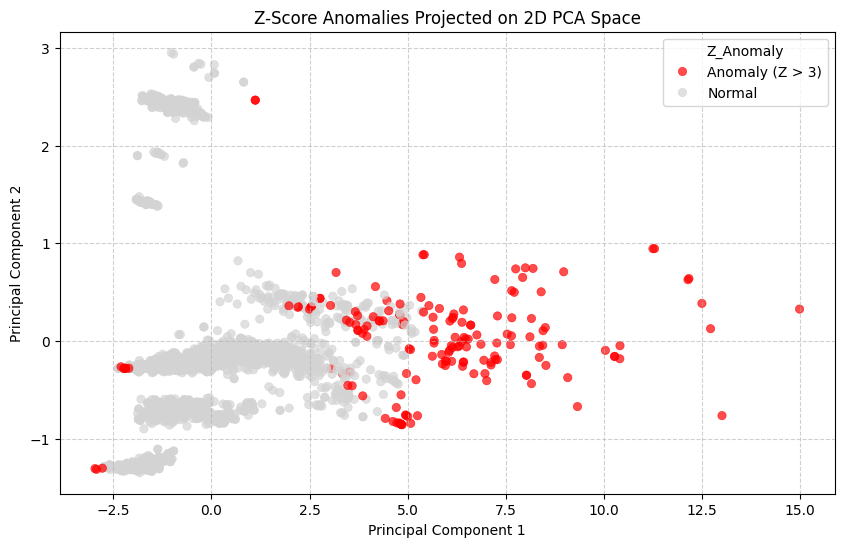

In [12]:
# --- Part 5.1: Z-Score Anomaly Detection ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Z-Score Anomaly Detection ---")
z_scores_abs = np.abs(df_scaled)

# Define the anomaly threshold (typically 3 standard deviations)
z_threshold = 3.0

# A row is considered an anomaly if ANY of its features has a Zscore > threshold
z_anomalies_mask = (z_scores_abs > z_threshold).any(axis=1)
num_z_anomalies = z_anomalies_mask.sum()

print(f"Threshold set to: Z > {z_threshold}")
print(f"Number of anomalies detected by Z-Score: {num_z_anomalies} (out of {len(df_scaled)} GPUs)")

# Let's see what kind of cards were flagged
print("\nSample of GPUs flagged as anomalies by Z-Score:")
display(df[['manufacturer', 'productName']][z_anomalies_mask].head(10))

# --- Visualize Z-Score Anomalies on the PCA Projection ---
plt.figure(figsize=(10, 6))

# Use our PCA dataframe from Part 3. We'll map the boolean mask to strings for the legend
pca_df['Z_Anomaly'] = z_anomalies_mask.map({True: 'Anomaly (Z > 3)', False: 'Normal'})

# Plot
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Z_Anomaly',
    palette={'Normal': 'lightgray', 'Anomaly (Z > 3)': 'red'},
    data=pca_df,
    alpha=0.7,
    edgecolor=None
)

plt.title('Z-Score Anomalies Projected on 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


5.2 Isolation Forest


Analysis and Discussion


**Isolation Mechanism:**
* Unlike traditional methods that profile "normal" instances and look for deviations, Isolation Forest explicitly identifies anomalies. The underlying logic is that anomalies are "few and different", making them highly susceptible to isolation. In a tree structure, anomalies will require significantly fewer splits to be perfectly isolated into their own leaf node, resulting in a notably shorter path length from the root.

**Random Partitioning:**
* The algorithm works by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of that selected feature. Because anomalies lie far away from the dense bulk of the data, this random splitting guarantees that anomalous points are partitioned and isolated much earlier in the process than normal points.

**Contamination Parameter:**
* The contamination parameter defines the expected proportion of anomalies in the dataset. It essentially sets the threshold for the decision function. If we set it to 0.05, the algorithm will label the top 5% of points with the shortest path lengths as anomalies. It requires domain knowledge to set correctly. If unknown, it can be set to auto.

**Advantages in High-Dimensional Settings:**
* In high dimensional spaces, distance based metrics lose their meaning because all points appear roughly equidistant. Isolation Forest does not rely on distance metrics or density calculations, nor does it assume the data is normally distributed (unlike ZScre). Since it processes subsets of features via random splits, it is exceptionally fast, highly scalable, and very robust to high dimensionality.

--- Isolation Forest Anomaly Detection ---
Number of anomalies detected by Isolation Forest: 153 (out of 3056 GPUs)

Sample of GPUs flagged as anomalies by Isolation Forest:


,manufacturer,productName
0,NVIDIA,GeForce RTX 5090
1,NVIDIA,GeForce RTX 5080
2,NVIDIA,GeForce RTX 5070
3,NVIDIA,GeForce RTX 5060 Mobile
4,NVIDIA,GeForce RTX 5060
6,NVIDIA,RTX 1000 Mobile Ada Generation
7,NVIDIA,GeForce RTX 3050 6 GB
8,AMD,Radeon Instinct MI325X
9,NVIDIA,RTX A400
10,NVIDIA,RTX 500 Mobile Ada Generation


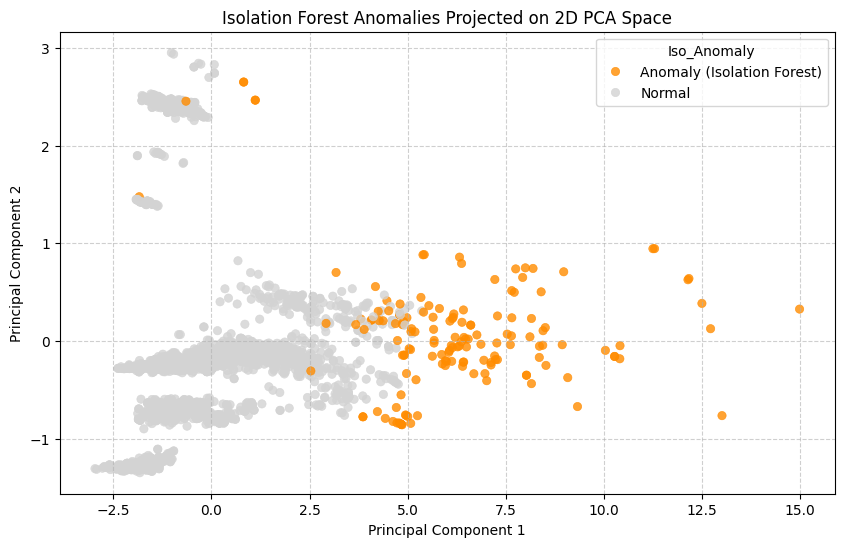

In [14]:
# --- Part 5.2: Isolation Forest Anomaly Detection ---

from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Isolation Forest Anomaly Detection ---")

# We set contamination to 0.05 (assuming the most extreme 5% of GPUs are true anomalies)
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# IsolationForest returns -1 for anomalies and 1 for normal points
iso_labels = iso_forest.fit_predict(df_scaled)

# Create a boolean mask for anomalies (where label is -1)
iso_anomalies_mask = (iso_labels == -1)
num_iso_anomalies = iso_anomalies_mask.sum()

print(f"Number of anomalies detected by Isolation Forest: {num_iso_anomalies} (out of {len(df_scaled)} GPUs)")

print("\nSample of GPUs flagged as anomalies by Isolation Forest:")
display(df[['manufacturer', 'productName']][iso_anomalies_mask].head(10))

# --- Visualize Isolation Forest Anomalies on the PCA Projection ---

plt.figure(figsize=(10, 6))
pca_df['Iso_Anomaly'] = np.where(iso_anomalies_mask, 'Anomaly (Isolation Forest)', 'Normal')

# Plot the anomalies in dark orange to differentiate from the Z-score plot
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Iso_Anomaly',
    palette={'Normal': 'lightgray', 'Anomaly (Isolation Forest)': 'darkorange'},
    data=pca_df,
    alpha=0.8,
    edgecolor=None
)

plt.title('Isolation Forest Anomalies Projected on 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


5.3 Local Outlier Factor (LOF)

Analysis and Discussion


**Local Density Estimation:**
* LOF computes the local density deviation of a given data point with respect to its neighbors. It compares the density of a point to the densities of its k nearest neighbors. If a point has a subtantially lower density than its neighbors (an LOF score significantly greater than 1), it is flagged as an outlier.

**Neighborhood Effects:**
* Because LOF evaluates points strictly based on their immediate local neighborhood, it brilliantly handles datasets with regions of varying densities. For example, a point situated slightly outside a very dense cluster will be flagged as an anomaly, whereas a point at the exact same absolute distance from a sparse cluster might be considered normal.

**Sensitivity to Parameter k:**
The algorithm is highly sensitive to the chosen k.
* If k is **too small**, the algorithm is overly sensitive to statistical noise and micro clusters.
* If k is **too large**, the "local" neighborhood effectively becomes global, and the algorithm loses its ability to detect true local outliers, making it behave more like standard global distance metrics. A rule of thumb is to use a k greater than the minimum number of points a cluster has to have, and smaller than the maximum number of close points that can potentially be outliers.

**Difference Between Global and Local Anomalies:**
* **Global Anomalies** are points that are extremely far from any other data in the entire dataset (like the RTX 5090).
* **Local Anomalies** are points that might not stand out in the grand scheme of the dataset but are structurally wrong for their specific neighborhood. For instance, a GPU from 2005 with an inexplicably high memory bandwidth compared only to other 2005 GPUs would be a local anomaly, even if that bandwidth is considered low by 2024 standards.

--- Local Outlier Factor (LOF) Anomaly Detection ---
Number of anomalies detected by LOF: 153 (out of 3056 GPUs)

Sample of GPUs flagged as anomalies by LOF:


,manufacturer,productName
6,NVIDIA,RTX 1000 Mobile Ada Generation
7,NVIDIA,GeForce RTX 3050 6 GB
8,AMD,Radeon Instinct MI325X
15,NVIDIA,GeForce RTX 4070 Ti SUPER
27,NVIDIA,GeForce RTX 4050 Mobile
28,NVIDIA,GeForce RTX 4050 Max-Q
29,Intel,Arc A380M
30,AMD,Radeon Instinct MI300X
31,AMD,Radeon Instinct MI300
32,Intel,Data Center GPU Max Subsystem


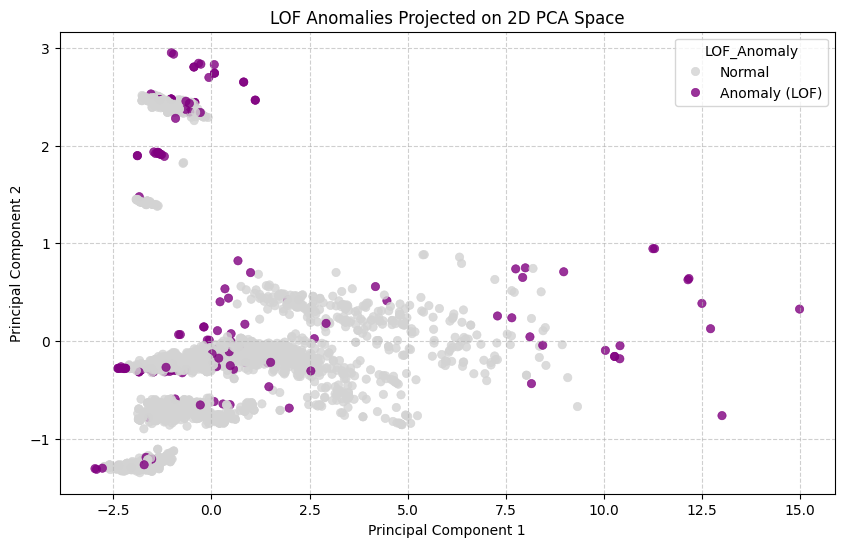

In [15]:
# --- Part 5.3: Local Outlier Factor (LOF) Anomaly Detection ---

from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Local Outlier Factor (LOF) Anomaly Detection ---")

# n_neighbors=20 is the default. We keep contamination=0.05 to compare with Isolation Forest
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# LOF returns -1 for anomalies and 1 for normal points
lof_labels = lof.fit_predict(df_scaled)

# Create a boolean mask for anomalies
lof_anomalies_mask = (lof_labels == -1)
num_lof_anomalies = lof_anomalies_mask.sum()

print(f"Number of anomalies detected by LOF: {num_lof_anomalies} (out of {len(df_scaled)} GPUs)")

print("\nSample of GPUs flagged as anomalies by LOF:")
display(df[['manufacturer', 'productName']][lof_anomalies_mask].head(10))

# --- Visualize LOF Anomalies on the PCA Projection ---
plt.figure(figsize=(10, 6))
pca_df['LOF_Anomaly'] = np.where(lof_anomalies_mask, 'Anomaly (LOF)', 'Normal')

# Plot the anomalies in purple to differentiate from the previous plots
sns.scatterplot(
    x='PC1', y='PC2',
    hue='LOF_Anomaly',
    palette={'Normal': 'lightgray', 'Anomaly (LOF)': 'purple'},
    data=pca_df,
    alpha=0.8,
    edgecolor=None
)

plt.title('LOF Anomalies Projected on 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. Comparison of Anomaly Detection Methods



**Shared vs. Method-Specific Anomalies**
* **Shared Anomalies:** All three methods successfully identified the absolute extremes of our dataset the modern "flagship" hardware like the **RTX 5090**, **RTX 5080**, and **Radeon Instinct MI325X**. These are so computationally powerful that they stand out regardless of the mathematical approach used.
* **Method-Specific:** **LOF** uniquely identified "local" anomalies, such as specific **Mobile / Max Q GPUs** and **Intel Arc** cards. These aren't the globally strongest cards, but their specific ratio of features (modern architecture but artificially limited clock speeds for laptops) makes them anomalous relative to their specific generation or peers. Z Score completely missed these because it only looks at global maximums.

**Sensitivity to Scaling**
* **Z Score:** Fundamentally requires scaling. It mathematically depends on mean and standard deviation, which are meaningless if features are on vastly different scales (GHz vs MB).
* **LOF:** Highly sensitive to scaling. Because it relies on Euclidean distance to find the k nearest neighbors, an unscaled feature with large raw numbers (like memSize in MB) would completely dominate the distance calculation over a feature with small numbers.
* **Isolation Forest:** Completely robust to scaling. Because it builds decision trees by randomly selecting a feature and splitting its values, the absolute scale of the features does not change the tree structure or the path length.

**Sensitivity to Dimensionality**
* **Z-Score:** Suffers greatly in high dimensions. It checks dimensions independently and cannot capture complex, multi dimensional correlations (high memory bandwidth paired with low clock speed).
* **LOF:** Suffers from the "Curse of Dimensionality." As dimensions increase, the distance between any two points tends to converge, making it extremely difficult to define a meaningful "local neighborhood".
* **Isolation Forest:** Excels in high dimensional spaces. By randomly sampling subsets of features to build its trees, it bypasses distance calculations entirely and remains highly effective even with hundreds of features.

**Runtime Considerations**
* **Z-Score:** Extremely fast. It is a simple vectorized mathematical operation.
* **Isolation Forest:** Very fast and highly scalable. It processes small sub samples of data to build trees, making it ideal for massive datasets.
* **LOF:** Computationally expensive (in worst cases without optimization) because it must calculate the pairwise distance between all points to establish local neighborhoods.

**Robustness to Noise**
* **Z-Score:** Low robustness. Global noise and extreme outliers heavily skew the global mean and standard deviation, effectively hiding other anomalies.
* **LOF:** Moderate robustness. Depends heavily on the k parameter, a bad k will cause the algorithm to mistake noise for local anomalies.
* **Isolation Forest:** Highly robust. Noise and normal points get buried deep within the tree structures, while true anomalies are isolated quickly near the root.

**Interpretability**
* **Z-Score:** Highly interpretable. You can point to the exact feature and mathematically state "this is exactly 3.5 standard deviations above the average."
* **LOF:** Low interpretability. A point is flagged based on a relative density ratio compared to k other points in multi dimensional space, which is incredibly difficult to visualize or explain to stakeholders.
* **Isolation Forest:** Moderate interpretability. While it's an ensemble of random trees, we can interpret the "Path Length" metric shorter paths explicitly mean the point was easier to isolate.

**False Positives vs. False Negatives**
* **Z-Score:** Prone to **False Positives** in heavily skewed distributions (like our GPU dataset), flagging perfectly valid, high performing modern cards just because they lie in the heavy right tail. It is also prone to **False Negatives** by missing multivariate anomalies.
* **Isolation Forest:** Requires a predefined contamination parameter. If set too low, it produces **False Negatives** (misses real anomalies). If set too high, it produces **False Positives** (forces normal points to be flagged).
* **LOF:** Prone to **False Positives** in datasets with naturally varying densities. A perfectly normal point on the slightly sparse edge of a dense cluster might be wrongly flagged as an outlier.

## 7. Critical Analysis and Reflection

Theoretical Challenges in Anomaly Detection

**Why anomaly detection is fundamentally difficult:**
* Anomaly detection is inherently challenging because the boundary between "normal" and "anomalous" is rarely well defined and often evolves over time (concept drift). Furthermore, datasets are typically highly imbalanced; you might have millions of normal records and only a handful of true anomalies, making it difficult to train robust models without overfitting to the few known examples.

**The Curse of Dimensionality & Problematic Distance:**
* As the number of features (dimensions) increases, the volume of the space grows exponentially. In extremely high dimensions, the mathematical distance ( Euclidean distance) between the nearest and the farthest point from any given origin converges to almost the same value. This means all points appear to be roughly equidistant from each other, rendering distance based algorithms (like K Means or standard LOF) completely blind and ineffective without prior dimensionality reduction.

**Noise vs. Anomaly:**
* While both noise and anomalies are deviations from the norm, their nature is completely different. **Noise** is random error, measurement variance, or environmental interference that should ideally be ignored or filtered out. An **Anomaly**, however, is a valid, true data point generated by a structurally different mechanism that we actively want to discover.

**The Danger of Assuming Gaussian Distributions:**
* Algorithms like the Z Score method strictly assume that data follows a normal (bell curve) distribution. In reality, modern datasets like computer hardware, wealth distribution, or internet traffic are heavily skewed with fat tails. Assuming a Gaussian distribution forces the model to label legitimate data points residing in the right / left tails as anomalies, leading to a massive rate of false positives.

**Why Visualization May Be Misleading After Dimensionality Reduction:**
* Techniques like PCA project high-dimensional data into 2D or 3D spaces to help us see it. However, this causes severe information loss. Two points that appear right next to each other in a 2D PCA plot might actually be vastly distant in the original 9-dimensional space, but PCA "crushed" them together from a certain angle. Conversely, points that are close in reality might be visually split. Relying solely on 2D plots to judge anomalies or clusters can lead to entirely false conclusions.

---
7.2 Ethical Considerations
---

Deploying anomaly detection systems in the real world carries immense ethical weight, as algorithms directly impact human lives:

**False Alarms:**
* If a system generates too many false positives, human operators (like doctors or security analysts) will experience "alert fatigue" and begin ignoring the system entirely. This renders the AI useless and guarantees that a true, critical anomaly will eventually be missed.

**Surveillance & Discrimination:**
* In public surveillance or HR tracking, anomaly detection is often trained on the "average" behavior of a majority population. Consequently, the system might flag minorities, people with physical disabilities, or neurodivergent individuals as "anomalous" simply because they act or move differently. This leads to unjust targeting and systemic discrimination encoded by math.

**Medical Applications:**
* In healthcare, the stakes are life and death. A **false positive** can cause a patient immense psychological trauma, financial ruin, and exposure to dangerous, unnecessary invasive biopsies. A **false negative** means a deadly disease goes untreated until it is too late. The threshold for what constitutes an anomaly here must be managed with extreme caution.

**Cybersecurity Applications:**
* In cybersecurity, an overly aggressive anomaly detector might block legitimate users from accessing critical infrastructure. While it stops hackers, it can severely disrupt normal human life and business operations if the definition of "normal network traffic" is too rigid.

## 8. Final Visualization Dashboard

Welcome to the interactive summary dashboard. This section integrates our findings into a single visual hub.
Below you will find:
1. **Feature Correlation Heatmap:** Displaying the linear relationships between all numerical features.
2. **Cluster Pairplot:** Visualizing how K-Means separated the data across key hardware metrics.
3. **Interactive Anomaly Explorer:** A dynamic widget that allows you to seamlessly toggle between the results of the Z-Score, Isolation Forest, and LOF models on the PCA projection.

--- Final Visualization Dashboard ---


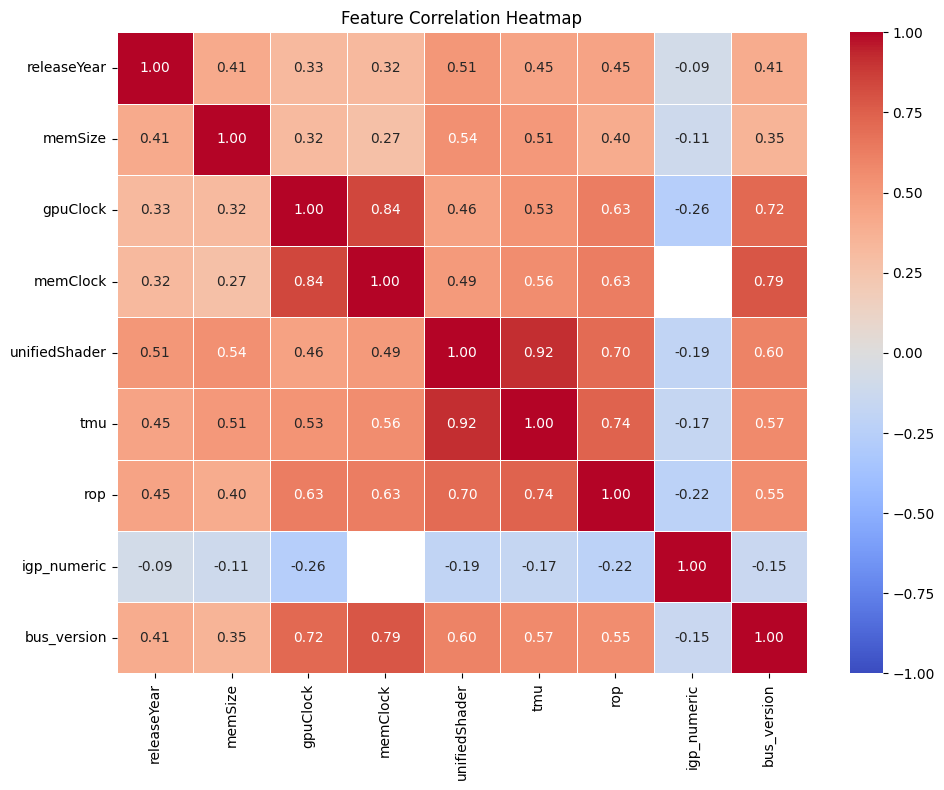

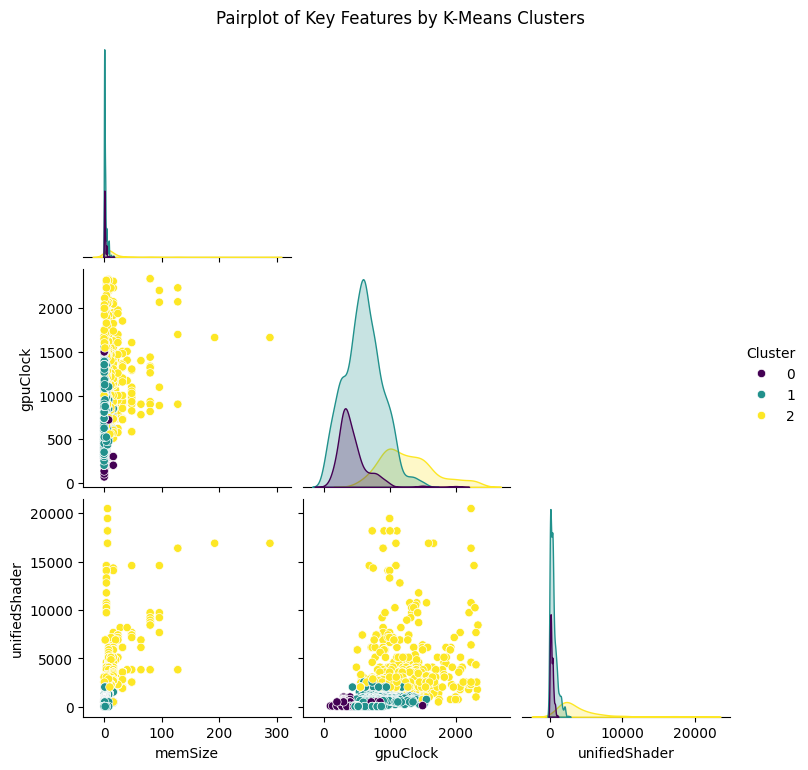


--- 🎛️ Interactive Anomaly Explorer ---
Select an anomaly detection method from the dropdown below to update the PCA graph:


interactive(children=(Dropdown(description='Method:', index=1, options=('Z-Score', 'Isolation Forest', 'LOF'),…

In [16]:
# --- Part 8: Final Visualization Dashboard ---
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

print("--- Final Visualization Dashboard ---")

# 1. Heatmap (Correlation Matrix)
plt.figure(figsize=(10, 8))
# We use df_numeric which contains all our cleaned numerical features
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 2. Pairplot (Using key features and K-Means clusters for clarity)
features_to_plot = ['memSize', 'gpuClock', 'unifiedShader']
pairplot_df = df[features_to_plot].copy()
pairplot_df['Cluster'] = pca_df['KMeans_Cluster'] # Borrowing the best clustering labels

# Plotting the pairplot
sns.pairplot(pairplot_df, hue='Cluster', palette='viridis', corner=True, diag_kind='kde')
plt.suptitle("Pairplot of Key Features by K-Means Clusters", y=1.02)
plt.show()

# 3. Interactive Anomaly Exploration
# This function dynamically updates the plot based on the dropdown selection
def explore_anomalies(Method):
    plt.figure(figsize=(10, 6))

    if Method == 'Z-Score':
        hue_col = 'Z_Anomaly'
        palette = {'Normal': 'lightgray', 'Anomaly (Z > 3)': 'red'}
    elif Method == 'Isolation Forest':
        hue_col = 'Iso_Anomaly'
        palette = {'Normal': 'lightgray', 'Anomaly (Isolation Forest)': 'darkorange'}
    elif Method == 'LOF':
        hue_col = 'LOF_Anomaly'
        palette = {'Normal': 'lightgray', 'Anomaly (LOF)': 'purple'}

    sns.scatterplot(x='PC1', y='PC2', hue=hue_col, palette=palette, data=pca_df, alpha=0.8, edgecolor=None)
    plt.title(f"Interactive Exploration: {Method} Anomalies")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Create the interactive dropdown menu
dropdown = widgets.Dropdown(
    options=['Z-Score', 'Isolation Forest', 'LOF'],
    value='Isolation Forest',
    description='Method:',
    style={'description_width': 'initial'}
)

print("\n--- 🎛️ Interactive Anomaly Explorer ---")
print("Select an anomaly detection method from the dropdown below to update the PCA graph:")
# Display the interactive widget
widgets.interact(explore_anomalies, Method=dropdown);